In [1]:
# Import libraries
import os

import pandas as pd
import polars as pl
import itertools
import numpy as np

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, auc, precision_recall_fscore_support, confusion_matrix, classification_report

In [2]:
# Declare the working directory and dataset directory
WORKING_DIR = '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank'
DATASET_DIR = '/group/pmc021/amunif/epi-thesis/workflow/08_HepG2/dataset'

# Loading the dataset

## Load the parquet file

In [3]:
X = pl.read_parquet(os.path.join(DATASET_DIR, 'X.parquet'))
X

index,index_right
u32,u32
0,0
0,1
0,2
0,3
0,4
…,…
22153,22149
22153,22150
22153,22151


In [4]:
y = pl.read_parquet(os.path.join(DATASET_DIR, 'y.parquet'))
y

label
i32
0
0
0
0
0
…
0
0
0


In [5]:
gene_id_features = pl.read_parquet(os.path.join(DATASET_DIR, 'gene_id_features.parquet'))
gene_id_features

index,gene_id,combined_features
u32,str,list[f64]
0,"""XLOC_000001""","[0.0, 0.0, … 0.0]"
1,"""XLOC_000003""","[0.0, 0.0, … 0.0]"
2,"""XLOC_000006""","[0.0, 0.0, … 0.0]"
3,"""XLOC_000007""","[0.0, 0.0, … 0.0]"
4,"""XLOC_000008""","[0.0, 0.0, … 0.0]"
…,…,…
22149,"""XLOC_030009""","[0.0, 0.0, … 0.0]"
22150,"""XLOC_030012""","[0.0, 0.0, … 0.0]"
22151,"""XLOC_030014""","[0.0, 0.0, … 0.0]"


## Convert to Numpy array

In [6]:
X_np = X.to_numpy()
y_np = y.to_numpy()
gene_id_features_np = gene_id_features.to_numpy()

In [7]:
print(X_np.shape)
print(y_np.shape)
print(gene_id_features_np.shape)

(490799716, 2)
(490799716, 1)
(22154, 3)


# Class and Utility Function

## Device initialization

In [8]:
def get_device():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    if device.type == "cuda":
        print(f"Current CUDA device: {torch.cuda.current_device()}")
        print(f"CUDA device name: {torch.cuda.get_device_name(0)}")

    return device

In [9]:
device = get_device()

Using device: cuda
Current CUDA device: 0
CUDA device name: Tesla P100-SXM2-16GB


## Custom Dataset

In [10]:
from torch.utils.data import Dataset

class HepG2Dataset(Dataset):
    def __init__(self, X, y, features):
        self.X = X
        self.y = y
        self.features = features

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        feature_1 = self.features[self.X[idx, 0], 2]
        feature_2 = self.features[self.X[idx, 1], 2]
        feature = np.concatenate((feature_1, feature_2), axis=0)
        return feature, self.y[idx]

## Split Data

In [11]:
def split_data(X, y):
    # Split the dataset into training, validation, and test sets
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.666, random_state=42, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

    return X_train, X_val, X_test, y_train, y_val, y_test

## Classifier Class

In [12]:
class BinaryClassifier(nn.Module):
    def __init__(self, input_size, hidden1_size=64, hidden2_size=32, output_size=1):
        super(BinaryClassifier, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, hidden1_size),
            nn.ReLU(),
            nn.Linear(hidden1_size, hidden2_size),
            nn.ReLU(),
            nn.Linear(hidden2_size, output_size),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x = x.squeeze(1)
        return self.network(x)

    def predict(self, x):
        with torch.no_grad():
            outputs = self.forward(x)
            return (outputs >= 0.5).long()

## Plotting Function

In [53]:
def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, num_items):
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(14, 6))
    
    # Plot for training and validation Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'blue', label='Training Loss')
    plt.plot(epochs, val_losses, 'orange', label='Validation Loss')
    plt.title(f'Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Plot for training and validation Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'blue', label='Training Accuracy')
    plt.plot(epochs, val_accuracies, 'orange', label='Validation Accuracy')
    plt.title(f'Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()

    img_name = f"ranking-{num_items}"
    plt.savefig(os.path.join(WORKING_DIR, 'output', 'img', 'train', img_name))
    
    plt.show()

# Experiments

## Split Dataset

In [66]:
# Choose the sample
num_items = 100_000
X_sample = X_np[:num_items]
y_sample = y_np[:num_items]

In [67]:
# Split data
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X_sample, y_sample)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(33400, 2)
(33300, 2)
(33300, 2)
(33400, 1)
(33300, 1)
(33300, 1)


## Prepare DataLoader

In [68]:
# Create dataset
from torch.utils.data import DataLoader

dataset = HepG2Dataset(X_train, y_train, gene_id_features_np)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True, pin_memory=True)

val_dataset = HepG2Dataset(X_val, y_val, gene_id_features_np)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=True, pin_memory=True)

test_dataset = HepG2Dataset(X_test, y_test, gene_id_features_np)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=True, pin_memory=True)

In [69]:
# Arrays for saving the performance metric

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_aucs, val_aucs = [], []
val_precisions = []
val_recalls = []
val_f1_scores = []

## Training and Validation Steps

In [77]:
# Initialize model
model = BinaryClassifier(input_size=40000).to(device)

# Define loss function for binary classification
criterion = nn.BCELoss()  # Binary Cross Entropy Loss

# Training loop example
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5

# Training loop
for epoch in range(num_epochs):
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0
    train_true_labels = []
    train_predicted_labels = []

    # Manual batch generation
    for X_batch, y_batch in dataloader:
        # Forward pass
        outputs = model(X_batch.to(dtype=torch.float32).to(device))
        loss = criterion(outputs, y_batch.to(dtype=torch.float32).to(device))

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate accuracy
        predictions = (outputs >= 0.5).long()

        train_loss += loss.item()
        train_correct += (predictions == y_batch.to(dtype=torch.float32).to(device)).sum().item()
        train_total += y_batch.size(0)
        train_true_labels.extend(y_batch.cpu().numpy())
        train_predicted_labels.extend(predictions.cpu().numpy())
        
    avg_train_loss = train_loss / len(dataloader)
    train_accuracy = 100 * train_correct / train_total
    train_auc_score = roc_auc_score(train_true_labels, train_predicted_labels)

    train_losses.append(round(avg_train_loss, 4))
    train_accuracies.append(round(train_accuracy, 2))
    train_aucs.append(round(train_auc_score, 2))

    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_metric = 0
    val_true_labels = []
    val_predicted_labels = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch.to(dtype=torch.float32).to(device))
            loss = criterion(outputs, y_batch.to(dtype=torch.float32).to(device))
            
            predictions = (outputs >= 0.5).long()
            
            val_loss += loss.item()
            val_correct += (predictions == y_batch.to(dtype=torch.float32).to(device)).sum().item()
            val_total += y_batch.size(0)
            val_true_labels.extend(y_batch.cpu().numpy())
            val_predicted_labels.extend(predictions.cpu().numpy())
            
        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_total
        val_metric = val_correct / len(val_loader)

        # Calculate precision, recall, and F1-score
        precision, recall, f1_score, _ = precision_recall_fscore_support(
            val_true_labels, 
            val_predicted_labels, 
            average='binary'  # Use macro average for multi-class classification
        )

        val_true_labels = np.array(val_true_labels)
        val_predicted_labels = np.array(val_predicted_labels)
        val_auc_score = roc_auc_score(val_true_labels, val_predicted_labels)

        val_losses.append(round(avg_val_loss, 4))
        val_accuracies.append(round(val_accuracy, 2))
        val_aucs.append(round(val_auc_score, 2))
        val_precisions.append(round(precision, 2))
        val_recalls.append(round(recall, 2))
        val_f1_scores.append(round(f1_score, 2))
    

    print(f'Epoch [{epoch+1}/{num_epochs}] - '
          f'[TRAIN] Loss: {avg_train_loss:.4f}, Accuracy: {train_accuracy:.2f}%, AUC: {train_auc_score:.2f} '
          f'[VAL] Loss: {avg_val_loss:.4f}, Accuracy: {val_accuracy:.2f}%, '
          f'Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1_score:.2f}, '
          f'AUC: {val_auc_score:.2f}')

Epoch [1/5] - [TRAIN] Loss: 0.5032, Accuracy: 73.69%, AUC: 0.68 [VAL] Loss: 0.4995, Accuracy: 77.65%, Precision: 0.84, Recall: 0.33, F1-Score: 0.47, AUC: 0.65
Epoch [2/5] - [TRAIN] Loss: 0.4850, Accuracy: 77.87%, AUC: 0.66 [VAL] Loss: 0.4901, Accuracy: 77.66%, Precision: 0.85, Recall: 0.32, F1-Score: 0.47, AUC: 0.65
Epoch [3/5] - [TRAIN] Loss: 0.4751, Accuracy: 77.93%, AUC: 0.66 [VAL] Loss: 0.4864, Accuracy: 77.65%, Precision: 0.84, Recall: 0.34, F1-Score: 0.48, AUC: 0.65
Epoch [4/5] - [TRAIN] Loss: 0.4708, Accuracy: 77.92%, AUC: 0.66 [VAL] Loss: 0.4898, Accuracy: 77.48%, Precision: 0.82, Recall: 0.34, F1-Score: 0.48, AUC: 0.65
Epoch [5/5] - [TRAIN] Loss: 0.4649, Accuracy: 78.12%, AUC: 0.66 [VAL] Loss: 0.4889, Accuracy: 77.47%, Precision: 0.82, Recall: 0.34, F1-Score: 0.48, AUC: 0.65


## Plotting the Training and Validation Result

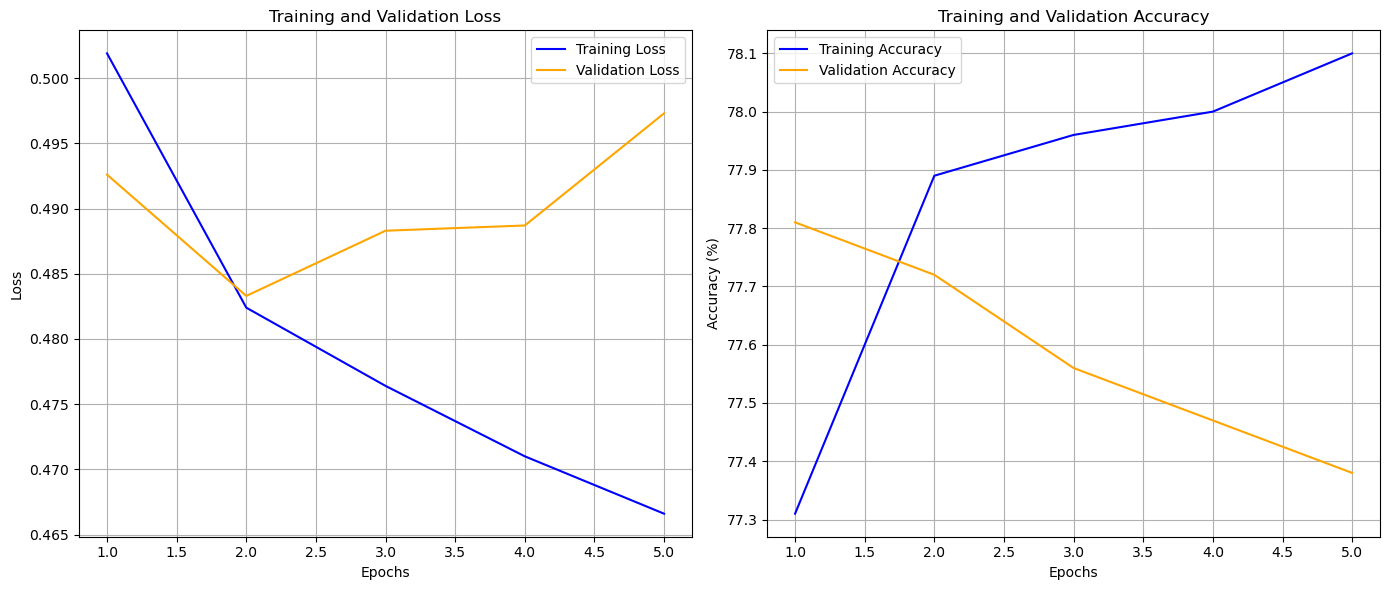

In [71]:
plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, num_items)

## Testing

In [72]:
# Predict on test set
test_predictions = []
test_true_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch.to(dtype=torch.float32).to(device))
        predictions = (outputs >= 0.5).long()
        test_true_labels.extend(y_batch.cpu().numpy())
        test_predictions.extend(predictions.cpu().numpy())

In [73]:
# Evaluation metrics
# Precision, Recall, F1-Score
precision, recall, f1_score, _ = precision_recall_fscore_support(
    test_true_labels, 
    test_predictions, 
    average='binary'  # Use 'macro' for multi-class
)

test_acc_score = accuracy_score(test_true_labels, test_predictions) * 100

print(f"Accuracy Score on test set: {test_acc_score:.2f} %")
test_auc_score = roc_auc_score(test_true_labels, test_predictions)
print(f"AUC Score on test set: {test_auc_score:.2f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(test_true_labels, test_predictions))

# Confusion Matrix
conf_matrix = confusion_matrix(test_true_labels, test_predictions)
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy Score on test set: 77.31 %
AUC Score on test set: 0.65
Precision: 0.8022
Recall: 0.3427
F1-Score: 0.4803

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.96      0.85     23114
           1       0.80      0.34      0.48     10186

    accuracy                           0.77     33300
   macro avg       0.79      0.65      0.67     33300
weighted avg       0.78      0.77      0.74     33300


Confusion Matrix:
[[22253   861]
 [ 6695  3491]]


## Saving All Metrics

In [74]:
# Training metrics
file_name = f"train-validation-metrics-{num_items}.csv"
result_file = os.path.join(WORKING_DIR, 'output', 'train', f"{file_name}")

experiment_results = {
    'train_loss'    : train_losses,
    'train_accuracy': train_accuracies,
    'train_auc'     : train_aucs,
    'val_loss'      : val_losses,
    'val_accuracy'  : val_accuracies,
    'val_auc'       : val_aucs
}

experiment_pl = pl.DataFrame(experiment_results)

experiment_pl.write_csv(result_file)

In [75]:
# Test output
test_name = f"test-metrics-{num_items}.csv"
test_file = os.path.join(WORKING_DIR, 'output', 'test',f"{test_name}")

test_results = {
    'test_acc'    : round(test_acc_score, 4),
    'test_auc'    : round(test_auc_score, 4)
}

test_pl = pl.DataFrame(test_results)
test_pl.write_csv(test_file)

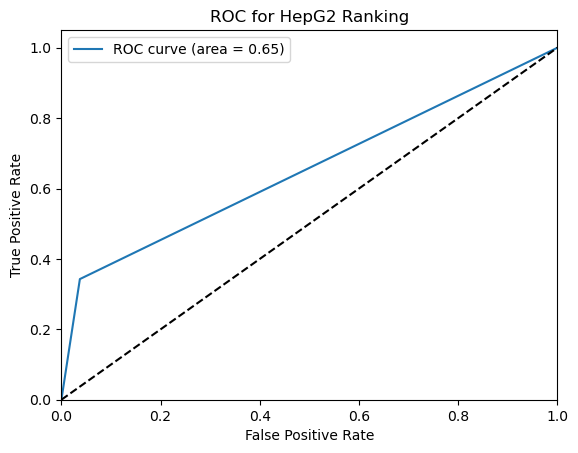

In [76]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_true_labels, test_predictions) 
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()  
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC for HepG2 Ranking')
plt.legend()

img_name = f"roc-{num_items}.png"
plt.savefig(os.path.join(WORKING_DIR, 'output', 'img', 'roc', img_name))

plt.show()